


<h1 style="margin-top:10px;">
## Lab 2: Seaborn (From Matplolib and pandas to seaborn)
</h1>

<h3>
Universidad de Antioquia <br>
Facultad de Ciencias Exactas y Naturales

Sebastian Eladio Mena Torres <br>
Física - 2026
</h3>

---

In [4]:
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#  1. Hacer el analisis estadístico de las variables: Millas por galón (mpg) vs potencia (horsepower) in the dataset: millas_por_galon.csv. Contruya el fit al $95$ C.L. Usar `seaborn`. Give some conclusions.

In [5]:
# Importar el dataset (ajustando la ruta relativa desde mi carpeta MENA_1209)
df = pd.read_csv('../../Sesiones/seaborn/millas_por_galon.csv')
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


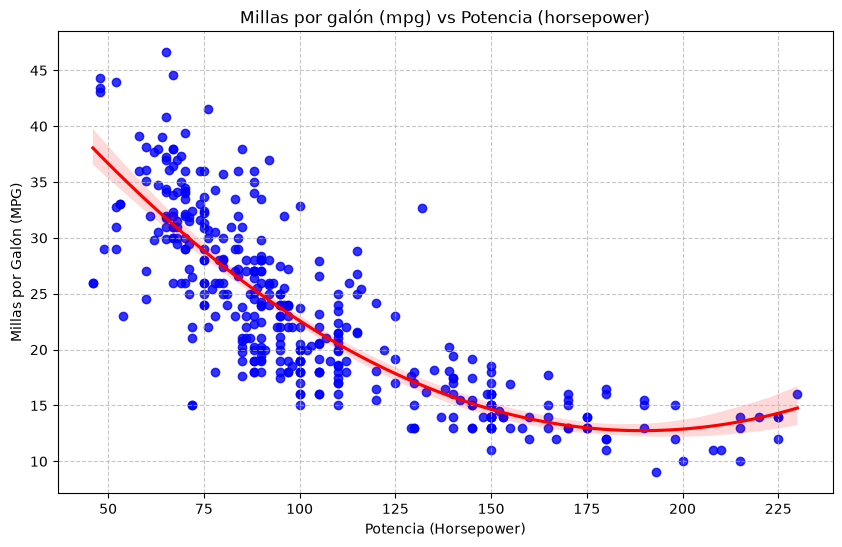

In [6]:
#  crear figura y tamaño
plt.figure(figsize=(10, 6))

# crear gráfico de dispersión con línea de regresión y (sombra de confianza al 95% esta por defecto en la función regplot, ci=95)
sns.regplot(data=df, x='horsepower', y='mpg', color='blue', line_kws={'color': 'red'}, ci=95, order=2)

# configurar el título y etiquetas de los ejes
plt.title('Millas por galón (mpg) vs Potencia (horsepower)')
plt.xlabel('Potencia (Horsepower)')
plt.ylabel('Millas por Galón (MPG)')
plt.grid(True, linestyle='--', alpha=0.7)

plt.show()

##  CONCLUSIONES

1. Se observa una clara correlación curvilinea negativa entre ambas variables; la curva muestra una caída muy pronunciada en el rendimiento para los vehículos de menor potencia (entre 50 y 100 horsepower), pero luego tiende a aplanarse gradualmente a medida que la potencia sigue subiendo, es decir, para generar mayor fuerza, el motor requiere quemar más combustible.

2. La mayor certeza predictiva se centra en el  rango de los 75 a 110 caballos de fuerza, ya que aquí es donde la franja sombreada de la linea roja tiene mayor estrechamiento.

3. En la vencidad del rango de los 75 caballos de fuerza, se observa una alta dispersión vertical en los puntos azules. En ese mismo nivel de potencia, hay autos que rinden 20MPG y otros 40MPG. Podemos concluir que aunque la potencia dicta la tendencia general también existen otras variables no graficadas que afectan fuertemente el rendimiento de los carros.

COLOCAR LA FUNCION DE REGRESION POLINOMIAL DE ORDEN 2, Y EL R2, Y EL ERROR ESTANDAR DE LA PENDIENTE Y LA INTERSECCION...

# 2. Descargar el dataframe : https://github.com/anferivera/SDdiracDM/blob/master/general-scan.csv desde GitHUb y reconstruir la figura 6 del [trabajo](https://journals.aps.org/prd/abstract/10.1103/PhysRevD.100.035029). Para ello usar `seaborn` y `matplolib`.

  * $M_N=h_s\dfrac{v_s}{\sqrt{2}}$ 
  * $v_s =$ vS
  * $h_s=$ YRC
  * $M_\Psi=$ MDF  
  * $M_{\chi_1^0}=$ mChi1
  * $\Omega_{\chi_1^0}=$ Omega
  * $\Omega_{DM}=0.12$

In [7]:
# Importar el dataset
url_raw = 'https://raw.githubusercontent.com/anferivera/SDdiracDM/master/general-scan.csv'


df_dm = pd.read_csv(url_raw)

df_dm.head()

,Unnamed: 0,MDF,MS12,MS22,LamS1H,LamS2H,LamSPH,LamS,LamSP,vS,...,U,mueg,taumug,sv,ZH11,ZH12,ZH21,ZH22,BRh1gg,BRh2gg
0,0,396.848661,2.137304e+06,2.137304e+06,0.020984,0.020984,0.020052,0.0,0.217236,702.109163,...,0.001075,0.0,1.773785e-19,1.860000e-26,0.999293,-0.037599,0.037599,0.999293,0.002837,0.000000
1,1,5988.499243,1.889315e+07,1.889315e+07,0.023341,0.023341,0.000181,0.0,0.019173,329.668504,...,-0.002513,0.0,1.791040e-18,2.580000e-31,0.001084,-0.999999,-0.999999,-0.001084,0.000342,0.002816
2,2,452.875632,2.469280e+06,2.469280e+06,0.000490,0.000490,0.017861,0.0,0.337367,3843.138599,...,0.000638,0.0,4.833919e-18,1.220000e-26,0.999994,-0.003384,0.003384,0.999994,0.002822,0.000000
3,3,589.443344,9.826674e+07,9.826674e+07,0.042790,0.042790,0.031174,0.0,0.270921,314.258778,...,0.000181,0.0,9.406560e-16,2.740000e-30,0.979480,-0.201541,0.201541,0.979480,0.002838,0.000194
4,4,1092.250036,2.054042e+06,2.054042e+06,0.002196,0.002196,0.002346,0.0,0.046671,13048.623894,...,0.000066,0.0,1.002187e-13,1.970000e-26,1.000000,-0.000945,0.000945,1.000000,0.002827,0.000000


In [8]:
# Calcular la nueva variable M_N

## M_N = h_s * (v_s / sqrt(2)) -> En el dataframe h_s es 'YRC' y v_s es 'vS'
df_dm['M_N'] = df_dm['YRC'] * (df_dm['vS'] / np.sqrt(2))

## Mostrar columnas y las primeras filas de la nueva variable M_N
print(df_dm.columns)
print(df_dm['M_N'].head())

Index(['Unnamed: 0', 'MDF', 'MS12', 'MS22', 'LamS1H', 'LamS2H', 'LamSPH',
       'LamS', 'LamSP', 'vS', 'YRD', 'YRC', 'YRA11', 'YRA12', 'YRA13', 'YRA21',
       'YRA22', 'YRA23', 'YRB11', 'YRB12', 'YRB13', 'YRB21', 'YRB22', 'YRB23',
       'mh1', 'mh2', 'mv3', 'mv2', 'mv1', 'mS1', 'mS2', 'mCha', 'mChi1',
       'mChi2', 'XV11', 'XV12', 'XV21', 'XV22', 'XU11', 'XU12', 'XU21', 'XU22',
       'vevSM', 'Omega', 'PSI', 'PSD', 'NSI', 'NSD', 'T', 'S', 'U', 'mueg',
       'taumug', 'sv', 'ZH11', 'ZH12', 'ZH21', 'ZH22', 'BRh1gg', 'BRh2gg',
       'M_N'],
      dtype='str')
0     132.558085
1     227.030952
2      59.890020
3     206.280709
4    7414.553232
Name: M_N, dtype: float64


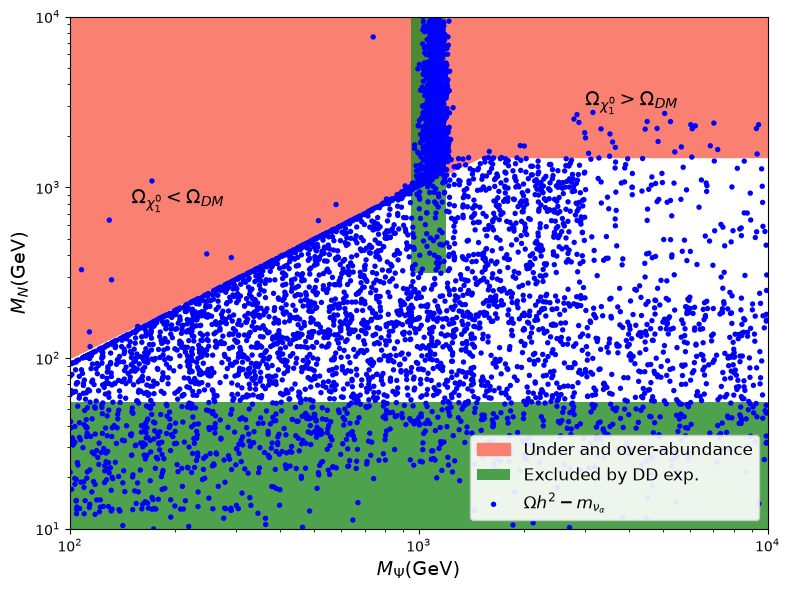

In [ ]:

# RECONSTRUCCIÓN DE LA FIGURA 6

## 1. Preparar la figura
fig, ax = plt.subplots(figsize=(8, 6))

## 2. Configurar ejes en escala logarítmica
ax.set_xscale('log')
ax.set_yscale('log')

# Limitar los ejes para que coincidan con la imagen (de 10^2 a 10^4 en X, y de 10^1 a 10^4 en Y)
ax.set_xlim(1e2, 1e4)
ax.set_ylim(1e1, 1e4)

# 3. Dibujar las áreas sombreadas

# --- Área Roja Superior Izquierda ---
# La línea divisoria con M_N = M_Psi (y=x). Rellenamos por encima de esa línea.
x_fill = np.logspace(2, 4, 100) # Creamos un vector de 100 puntos entre 10^2 y 10^4
ax.fill_between(x_fill, x_fill, 1e4, color='salmon', label='Under and over-abundance')

# --- Área Roja Superior Derecha ---
# Hay una zona plana a la derecha, aproximadamente desde x=1000, M_N > 1500
ax.fill_betweenx([1500, 1e4], 1000, 1e4, color='salmon')

# --- Área Verde Inferior ---
# Rellenamos desde M_N = 10 hasta M_N ~ 55
ax.axhspan(1e1, 55, facecolor='forestgreen', alpha=0.8, label='Excluded by DD exp.')

# --- Franja Verde Vertical ---
# Rellenamos una pequeña franja vertical alrededor de M_Psi = 1000
ax.axvspan(950, 1200, ymin=0.5, ymax=1, facecolor='forestgreen', alpha=0.8)


# 4. Graficar los puntos (Scatter plot)
# M_Psi corresponde a la columna 'MDF'
sns.scatterplot(
    data=df_dm, 
    x='MDF', 
    y='M_N', 
    color='blue', 
    s=15, # Tamaño de los puntos
    edgecolor='none', # Sin borde para que se vean como en la imagen
    label=r'$\Omega h^2 - m_{\nu_\alpha}$',
    ax=ax # Le decimos a seaborn que dibuje sobre el eje 'ax' que ya configuramos
)

# 5. Etiquetas y Leyenda
ax.set_xlabel(r'$M_\Psi$(GeV)', fontsize=14)
ax.set_ylabel(r'$M_N$(GeV)', fontsize=14)

# Configurar la leyenda
ax.legend(loc='lower right', fontsize=12, framealpha=0.9)

# Añadir los textos sobre el gráfico
ax.text(1.5e2, 8e2, r'$\Omega_{\chi_1^0} < \Omega_{DM}$', fontsize=14, weight='bold')
ax.text(3e3, 3e3, r'$\Omega_{\chi_1^0} > \Omega_{DM}$', fontsize=14, weight='bold')

plt.tight_layout()
plt.show()

VALE. SE VE BIEN. PERO LAS ZONAS NO USAN PANDAS, SOLO EL FILLBETWEEN
NOTA 2.3+2.4